In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [57]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

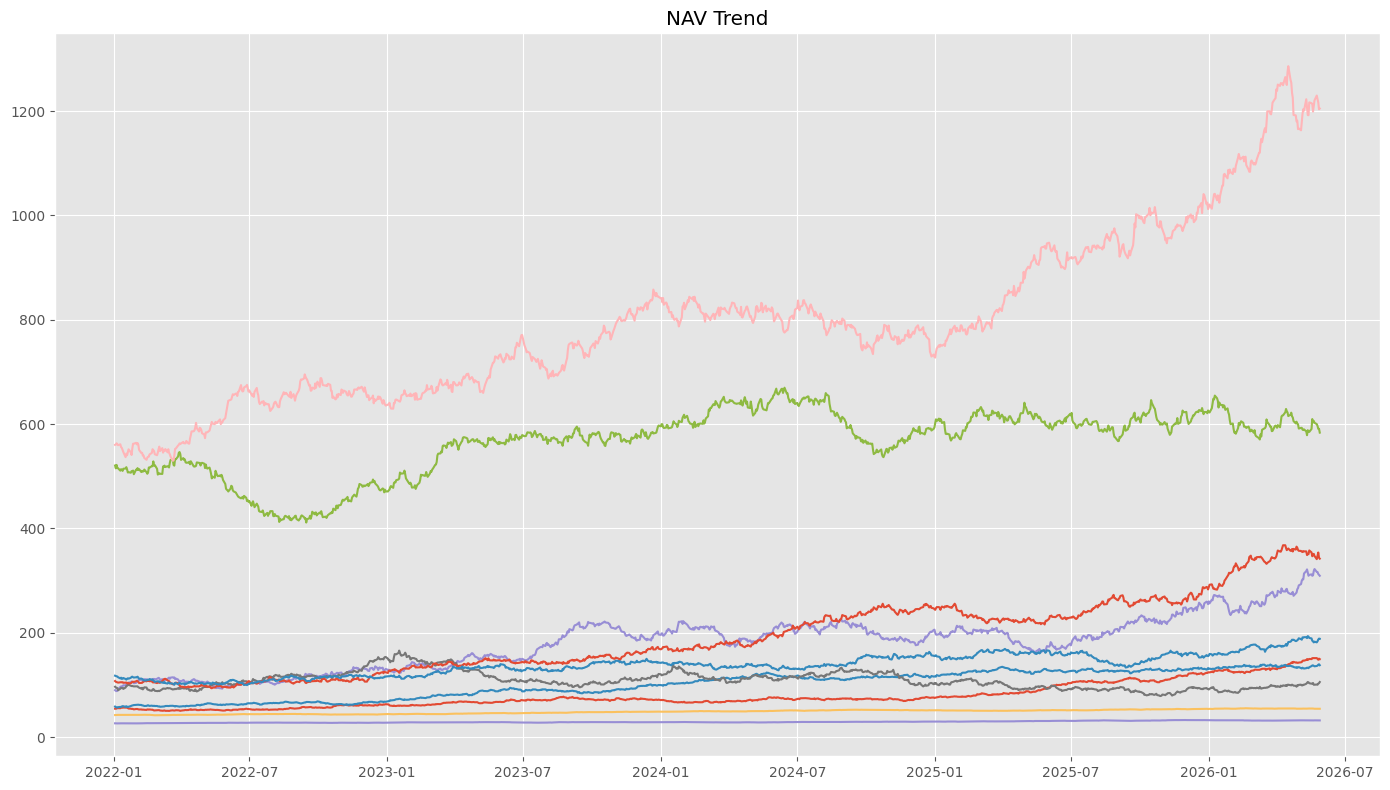

In [99]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(14,8))

for fund in nav["amfi_code"].unique()[:10]:
    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["nav"]
    )

plt.title("NAV Trend")

plt.tight_layout()
plt.savefig("../charts/nav_trend.png")   # <-- ADD THIS

plt.show()

In [59]:
import nbformat
print(nbformat.__version__)

5.10.4


In [60]:
import plotly.io as pio

pio.renderers.default = "browser"
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code"
)

fig.show()

In [61]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.shape)
aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [62]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [63]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


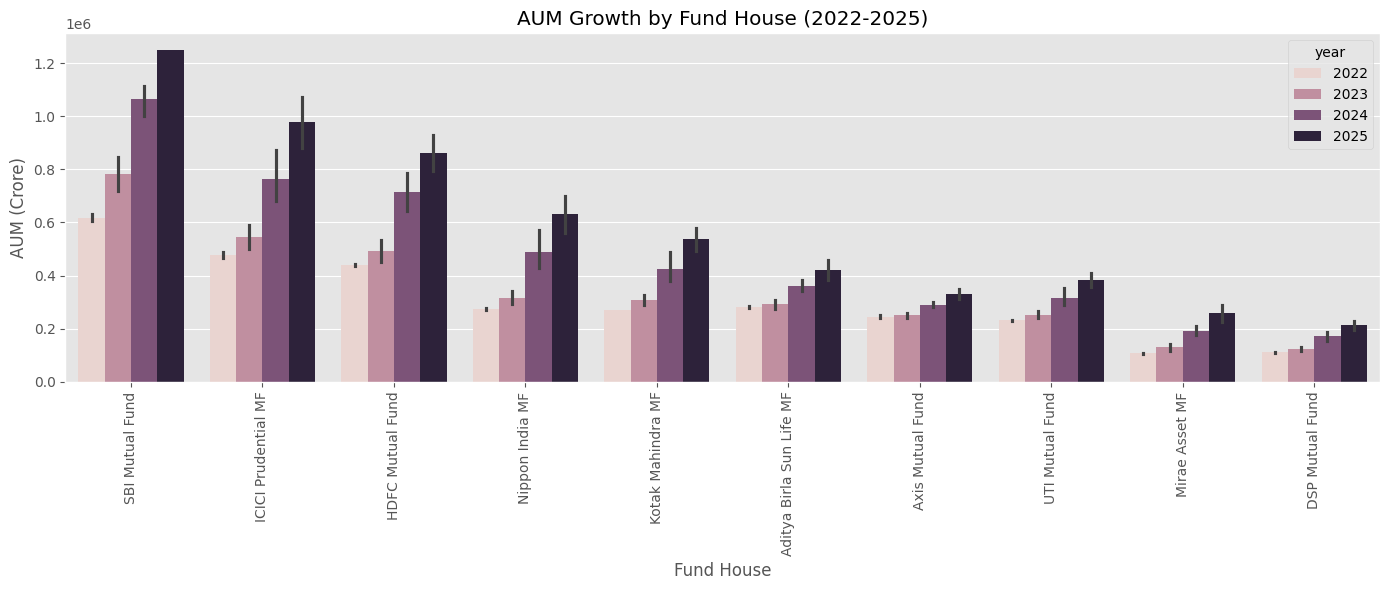

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.tight_layout()

plt.savefig("../charts/aum_growth.png", dpi=300)   # <-- ADD THIS

plt.show()

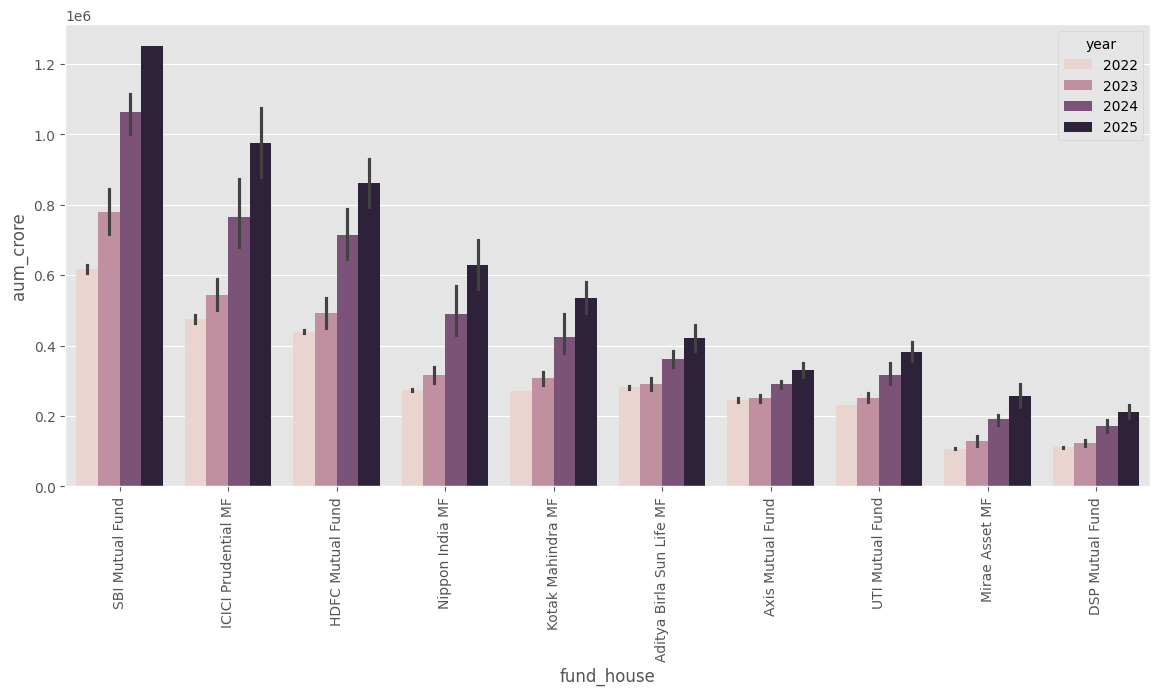

In [65]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=90)

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 2

SBI Mutual Fund consistently maintained the highest AUM among major fund houses, demonstrating strong market leadership throughout the period.

In [66]:
sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

print(sip.columns.tolist())
sip.head()

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [67]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

In [68]:
sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [69]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High ₹31,002 Cr",
    showarrow=True
)

fig.show()

In [70]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.columns)
category.head()

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [71]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


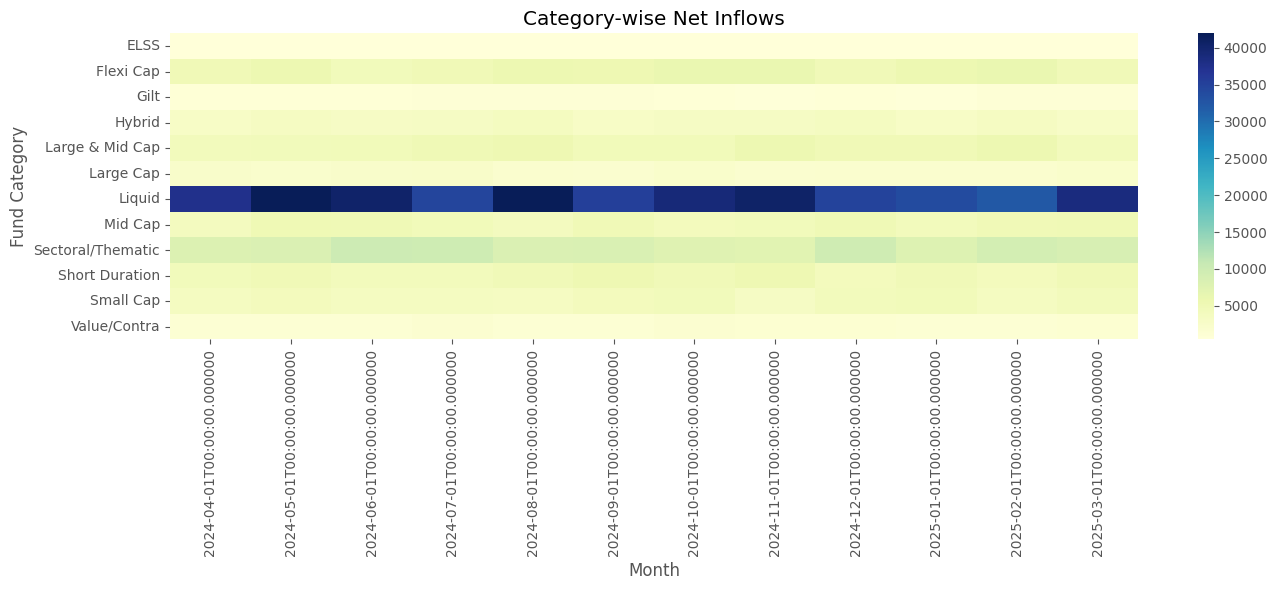

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 3

Flexi Cap, Mid Cap, and Small Cap categories attracted the strongest inflows, indicating sustained investor preference for growth-oriented equity funds.

In [73]:
investor = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


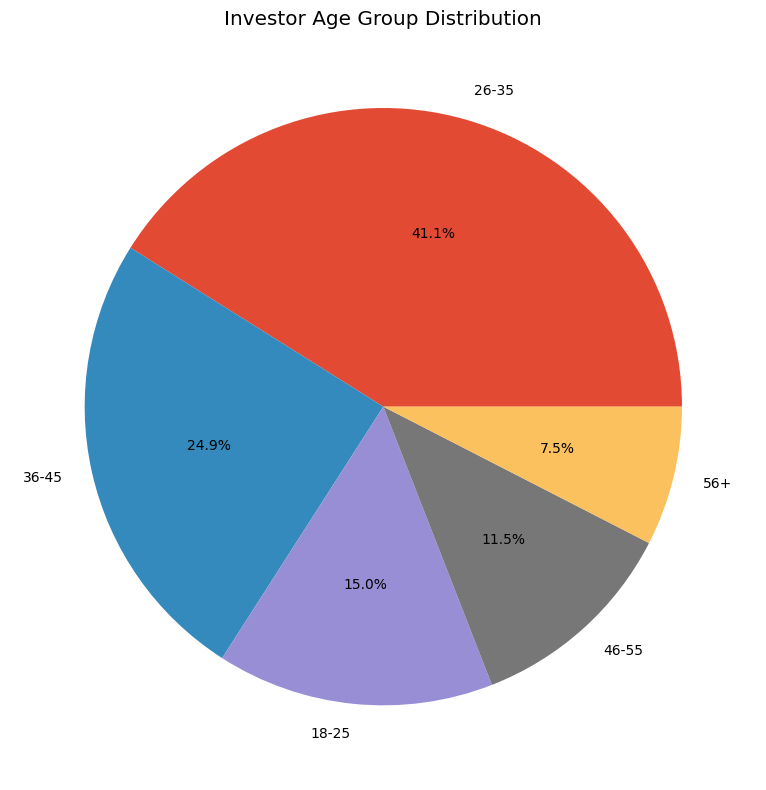

In [102]:
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

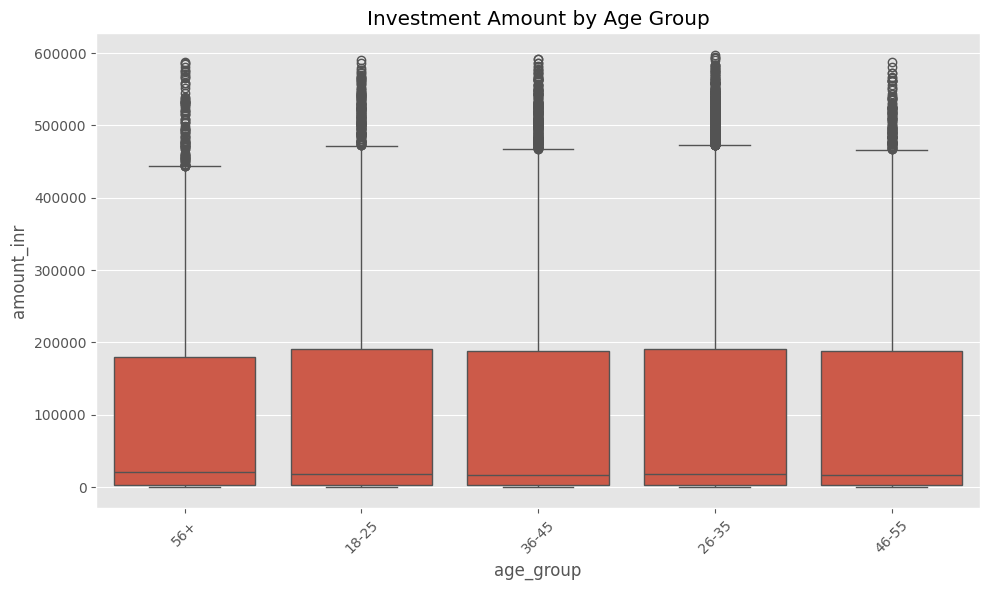

In [103]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/sip_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

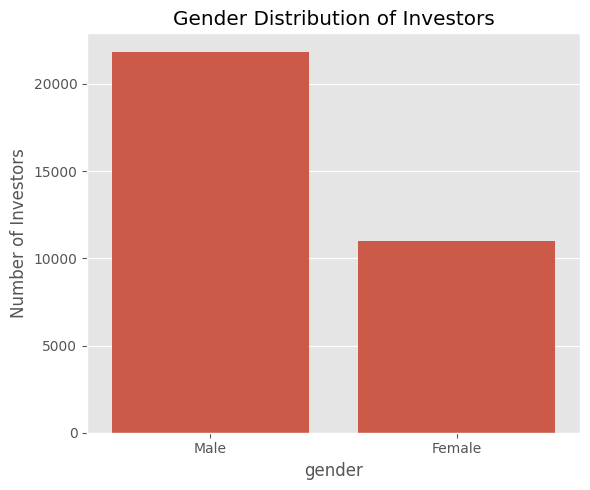

In [104]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    "../charts/gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 4

The 26–45 age group contributes the largest share of investments, indicating that working professionals form the core mutual fund investor base.

### Insight 5

Male investors constitute a larger share of transactions, though female participation remains significant across all age groups.

In [77]:
print(investor[["state","city_tier","amount_inr"]].head())

         state city_tier  amount_inr
0    Telangana       T30        1834
1       Punjab       B30      392882
2      Haryana       B30         912
3  Maharashtra       T30        1102
4        Delhi       T30        8682


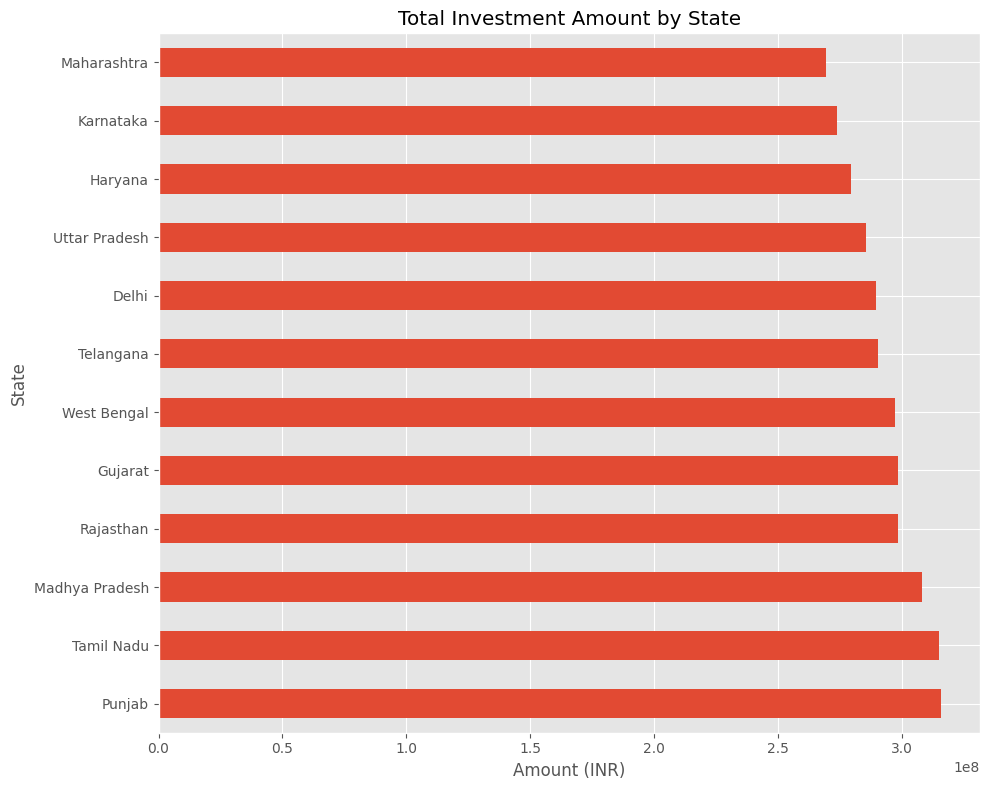

In [105]:
state_amount = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

state_amount.plot(kind="barh")

plt.title("Total Investment Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../charts/state_investment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

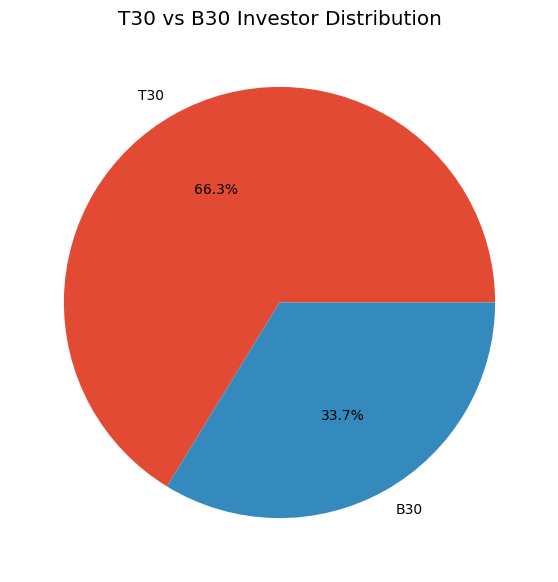

In [79]:
tier_counts = investor["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

### Insight 6

Metro and Tier-1 states contribute the majority of mutual fund investments, highlighting stronger penetration in developed financial markets.

### Insight 7

T30 cities account for a significant share of investments, though B30 participation continues to expand steadily.

In [80]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns.tolist())
folio.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [81]:
folio["month"] = pd.to_datetime(folio["month"])

In [82]:
import plotly.express as px

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Growth (2022-2025)"
)

fig.show(renderer="browser")

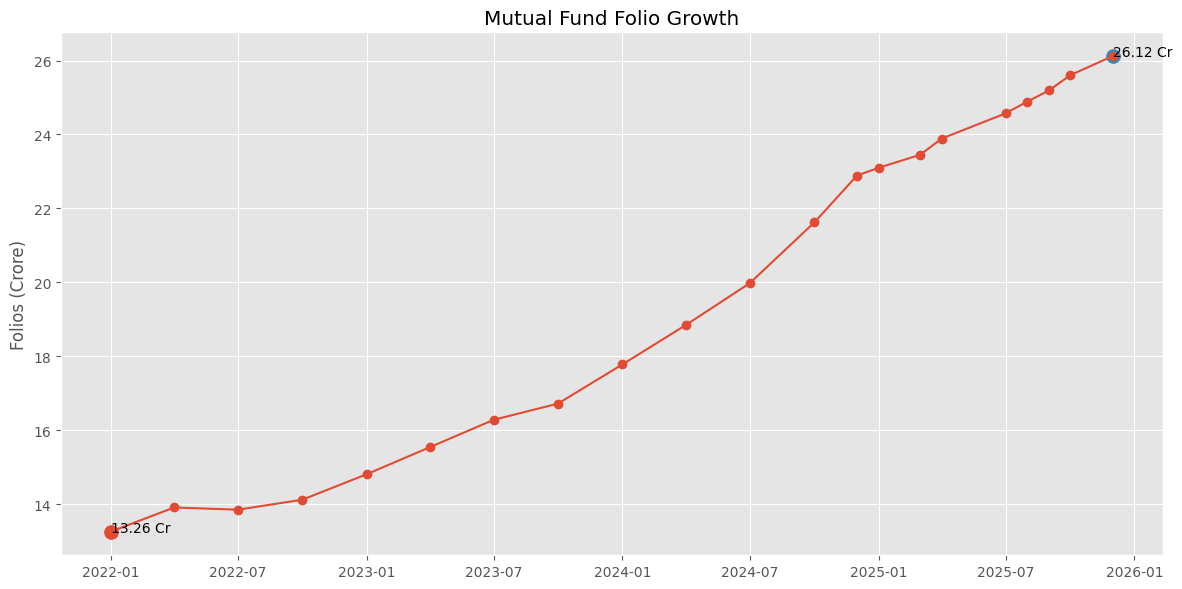

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.scatter(
    folio.iloc[0]["month"],
    folio.iloc[0]["total_folios_crore"],
    s=100
)

plt.scatter(
    folio.iloc[-1]["month"],
    folio.iloc[-1]["total_folios_crore"],
    s=100
)

plt.annotate(
    "13.26 Cr",
    (
        folio.iloc[0]["month"],
        folio.iloc[0]["total_folios_crore"]
    )
)

plt.annotate(
    "26.12 Cr",
    (
        folio.iloc[-1]["month"],
        folio.iloc[-1]["total_folios_crore"]
    )
)

plt.title("Mutual Fund Folio Growth")
plt.ylabel("Folios (Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 8

Industry folio counts nearly doubled during the study period, reflecting rapid expansion of retail participation in mutual funds.

In [84]:
print(nav["amfi_code"].nunique())

40


In [85]:
selected_funds = nav["amfi_code"].unique()[:10]

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [86]:
corr_data = nav[
    nav["amfi_code"].isin(selected_funds)
]

pivot_nav = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_nav.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [87]:
returns = pivot_nav.pct_change()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660


In [88]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


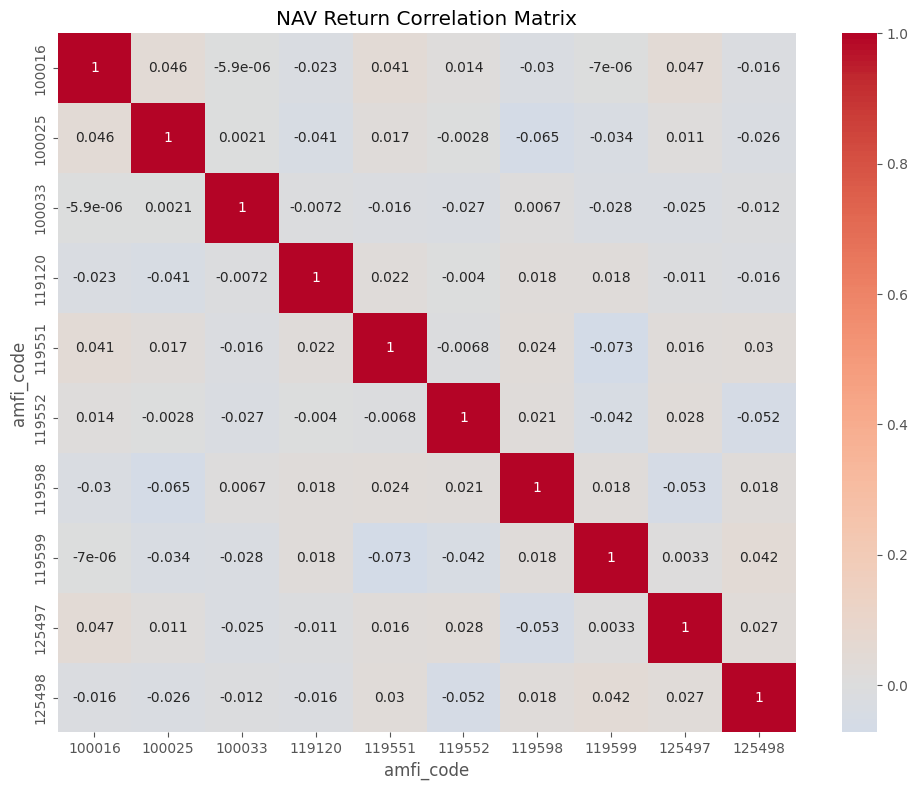

In [107]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 9

Most equity-oriented funds exhibit positive correlations, reflecting common exposure to broader market movements.

In [90]:
portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.columns.tolist())
portfolio.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [91]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

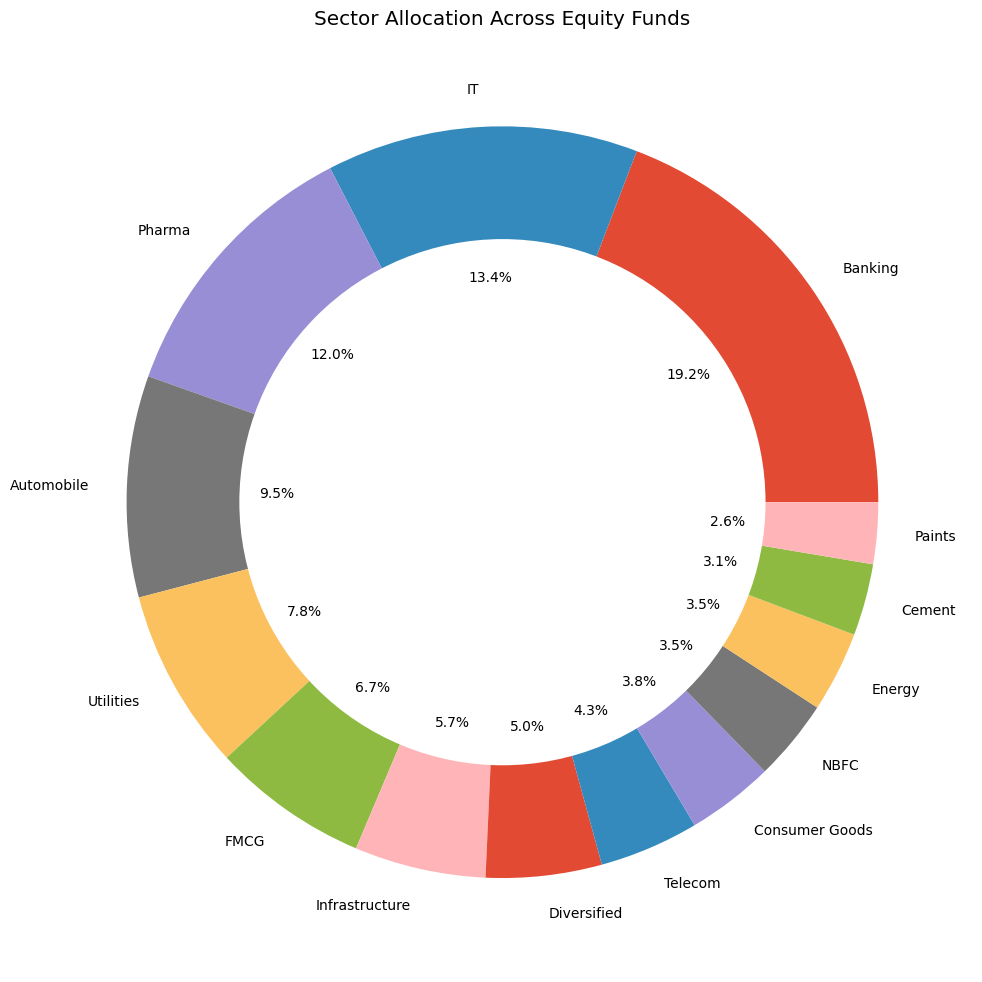

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig(
    "../charts/sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 10

Banking, Financial Services, and diversified sectors collectively account for the largest portfolio allocations, reflecting their importance in equity fund construction.

In [93]:
len([
    "Insight 1","Insight 2","Insight 3","Insight 4","Insight 5",
    "Insight 6","Insight 7","Insight 8","Insight 9","Insight 10"
])

10

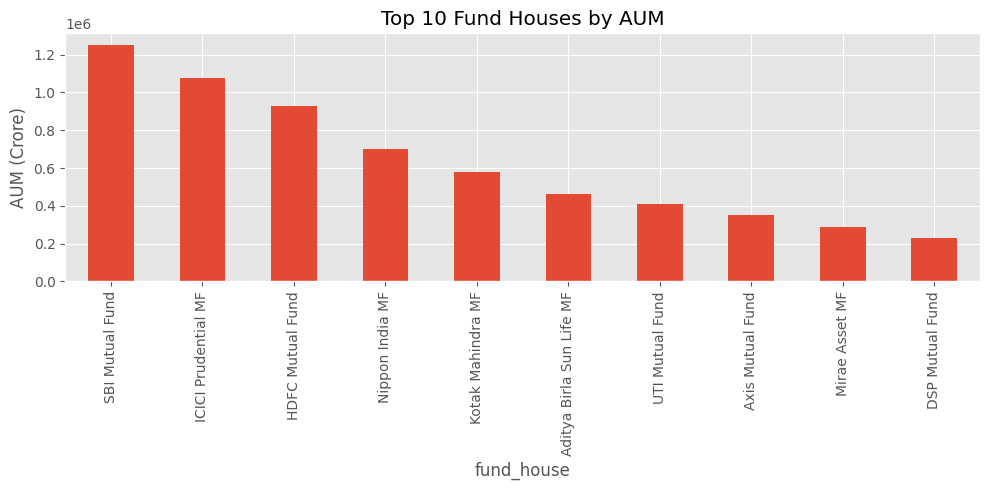

In [109]:
top10 = (
    aum.groupby("fund_house")["aum_crore"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top10.plot(kind="bar")

plt.title("Top 10 Fund Houses by AUM")
plt.ylabel("AUM (Crore)")

plt.tight_layout()

plt.savefig(
    "../charts/top10_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

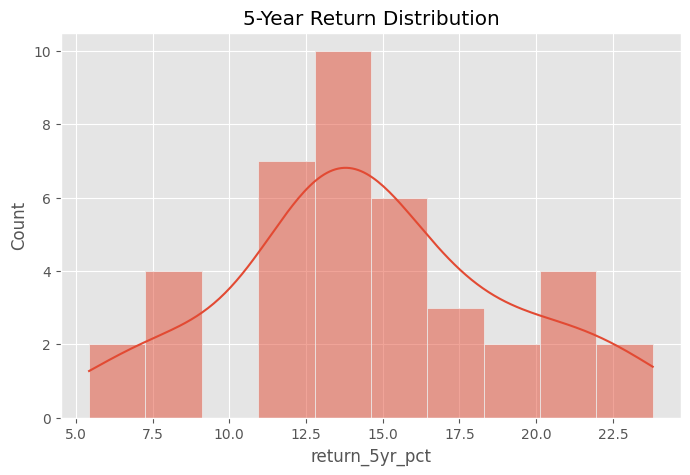

In [95]:
plt.figure(figsize=(8,5))

sns.histplot(
    performance["return_5yr_pct"],
    bins=10,
    kde=True
)

plt.title("5-Year Return Distribution")
plt.show()

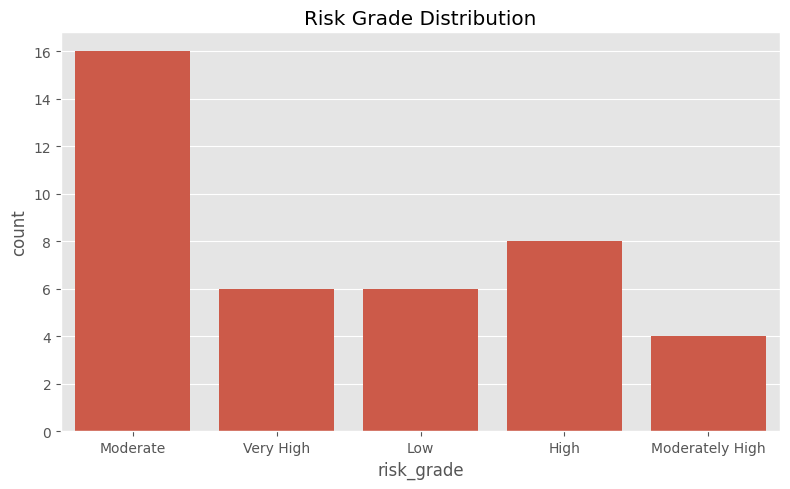

In [110]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 11

AUM remains concentrated among a small group of large fund houses, indicating a highly competitive industry structure.

### Insight 12

Most schemes generate moderate-to-high long-term returns, with only a few outliers on either side.

### Insight 13

High and Very High risk categories dominate the dataset, reflecting the popularity of growth-oriented mutual fund products.

In [97]:
plt.savefig("../charts/nav_trend.png")

<Figure size 640x480 with 0 Axes>

In [98]:
import os

os.makedirs("../charts", exist_ok=True)

print(os.listdir(".."))

['.git', '.gitignore', 'charts', 'dashboard', 'data', 'data_ingestion.py', 'live_nav_fetch.py', 'notebooks', 'reports', 'requirements.txt', 'sql', 'tempCodeRunnerFile.py']


In [111]:
import os

files = sorted(os.listdir("../charts"))

for f in files:
    print(f)

print("\nTotal Files:", len(files))

age_distribution.png
aum_growth.png
category_heatmap.png
correlation_heatmap.png
folio_growth.png
gender_split.png
nav_trend.png
risk_grade_distribution.png
sector_allocation.png
sip_boxplot.png
state_investment.png
top10_aum.png

Total Files: 12


In [112]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


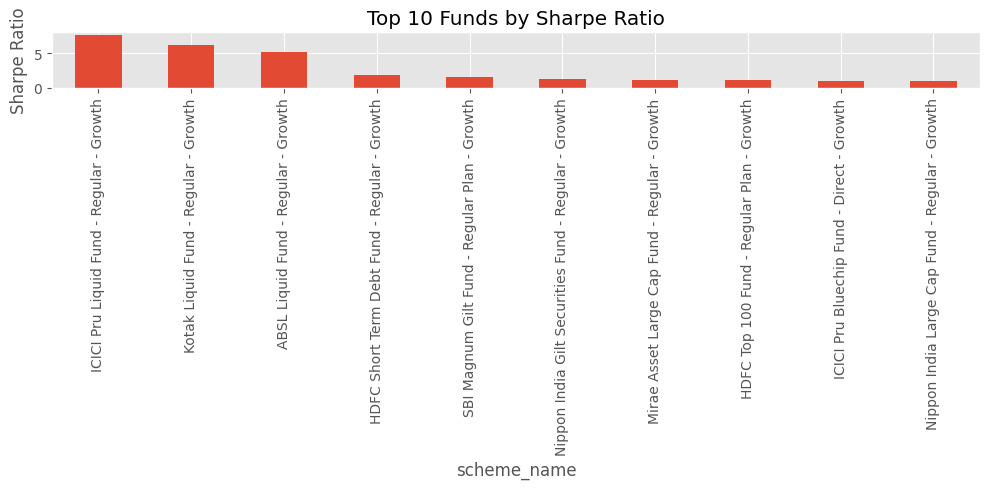

In [113]:
top_sharpe = (
    performance.groupby("scheme_name")["sharpe_ratio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_sharpe.plot(kind="bar")
plt.title("Top 10 Funds by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()

plt.savefig("../charts/top10_sharpe.png")
plt.show()

In [114]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


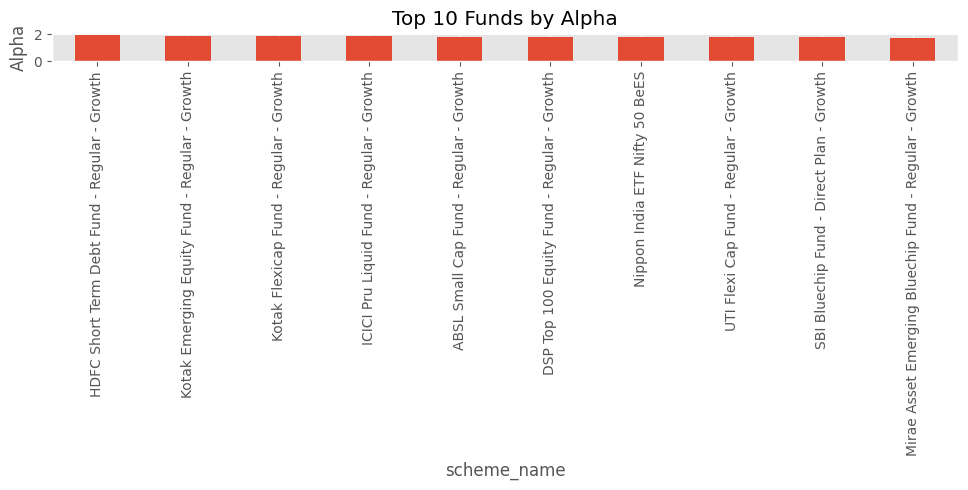

In [115]:
top_alpha = (
    performance.groupby("scheme_name")["alpha"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_alpha.plot(kind="bar")
plt.title("Top 10 Funds by Alpha")
plt.ylabel("Alpha")
plt.tight_layout()

plt.savefig("../charts/top10_alpha.png")
plt.show()

In [116]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


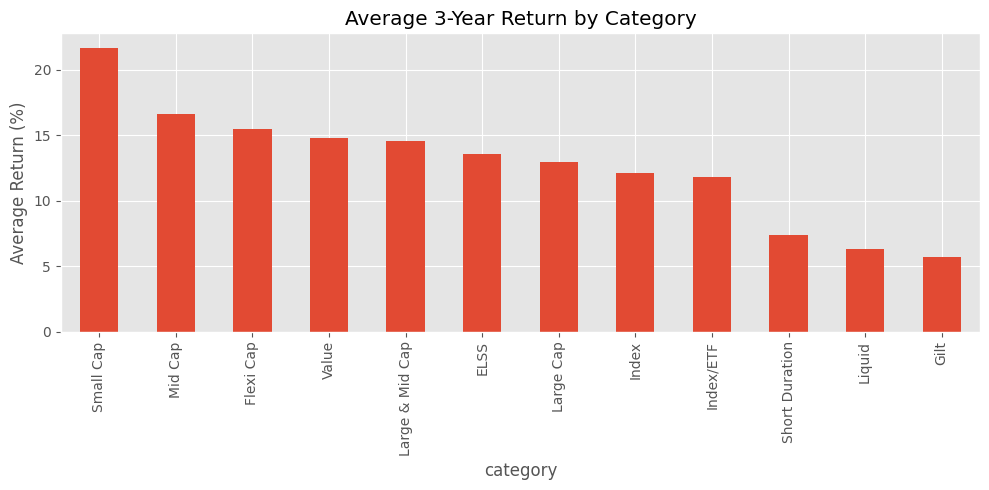

In [118]:
cat_return = (
    performance.groupby("category")["return_3yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

cat_return.plot(kind="bar")

plt.title("Average 3-Year Return by Category")
plt.ylabel("Average Return (%)")

plt.tight_layout()

plt.savefig("../charts/category_returns.png")

plt.show()